# How to regrid ocean output?

In [1]:
# Import python packages
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import os
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cf
import scipy
from glob import glob

import intake_esm
import intake
import pandas
import xarray
import gcsfs
import warnings
#suppress some annoying future warning
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=xr.SerializationWarning)
%matplotlib inline

In [2]:
# load exemplary data for ocean output, here eastward component of ocean stream velocity, and check what's inside
path = '/mnt/clinfra-ns12127k-ns9034k-cmip6/CMIP/NCC/NorESM2-LM/historical/r1i1p1f1/Omon/uo/gr/v20190815/'
files_uo_his = list(glob(path+"*.nc"))
files_uo_his.sort() # sorts files in ascending order, useful to have outputs sorted in accordance with years
NORESM2_LM_uo = xr.open_mfdataset(files_uo_his[0]) 
NORESM2_LM_uo

<xarray.Dataset> Size: 5GB
Dimensions:             (time: 120, bnds: 2, lev: 70, j: 385, i: 360,
                         vertices: 4)
Coordinates:
  * time                (time) object 960B 1850-01-16 12:00:00 ... 1859-12-16...
  * lev                 (lev) float64 560B 0.0 5.0 10.0 ... 6.5e+03 6.75e+03
  * j                   (j) int32 2kB 1 2 3 4 5 6 7 ... 380 381 382 383 384 385
  * i                   (i) int32 1kB 1 2 3 4 5 6 7 ... 355 356 357 358 359 360
    latitude            (j, i) float64 1MB dask.array<chunksize=(385, 360), meta=np.ndarray>
    longitude           (j, i) float64 1MB dask.array<chunksize=(385, 360), meta=np.ndarray>
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) object 2kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lev_bnds            (lev, bnds) float64 1kB dask.array<chunksize=(70, 2), meta=np.ndarray>
    vertices_latitude   (j, i, vertices) float64 4MB dask.array<chunksize=(193, 180, 2), meta=np.ndarray>
    vertices_longitude  (j, i, vertices) float64 4MB dask.array<chunksize=(193, 180, 2), meta=np.ndarray>
    uo                  (time, lev, j, i) float32 5GB dask.array<chunksize=(1, 24, 129, 120), meta=np.ndarray>
Attributes: (12/48)
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    branch_method:             Hybrid-restart from year 1600-01-01 of piControl
    branch_time:               0.0
    branch_time_in_child:      0.0
    branch_time_in_parent:     430335.0
    ...                        ...
    title:                     NorESM2-LM output prepared for CMIP6
    variable_id:               uo
    variant_label:             r1i1p1f1
    license:                   CMIP6 model data produced by NCC is licensed u...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/cfcbada2-a3ca-46f1-8472-4cad9474f6da

The data are stored on a j,i grid, each of which (j,i) pair has a corresponding latitude and longitude as you can see from the xarray information sheet. It states it's stored on a *tripolar grid* (research this on your own).

Let's have a look at the actual data..

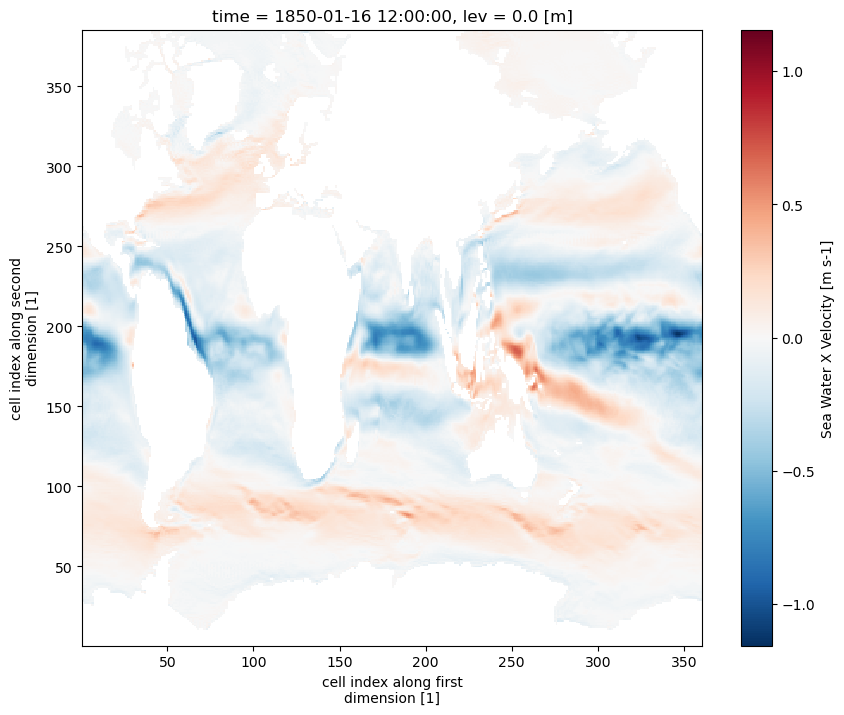

In [3]:
mpl.rcParams['figure.figsize'] = [10., 8.]
NORESM2_LM_uo.uo.isel(time=0,lev=0).plot() # I choose an arbitrary timestamp to get a snapshot, as well as a level (oups, what's a level here?)

This is the array / output as it looks like in original from the tripolar grid, you can see how it is distorted.

Note: if you change the depth level here, you can see how the ocean basin is defined, and where it is not defined anymore.
The output is only available where the ocean is defined, i.e. it follows the ocean bed topography.

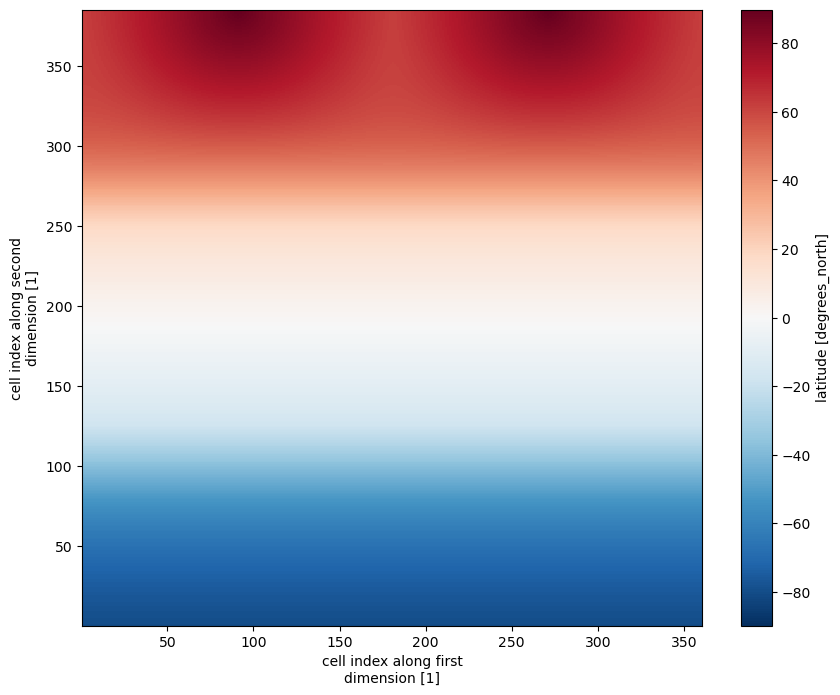

In [4]:
# in the plots of latitude and longitude you can clearly see the three poles (think a bit about how the next two plots come together as 3 poles)
NORESM2_LM_uo.latitude.plot()

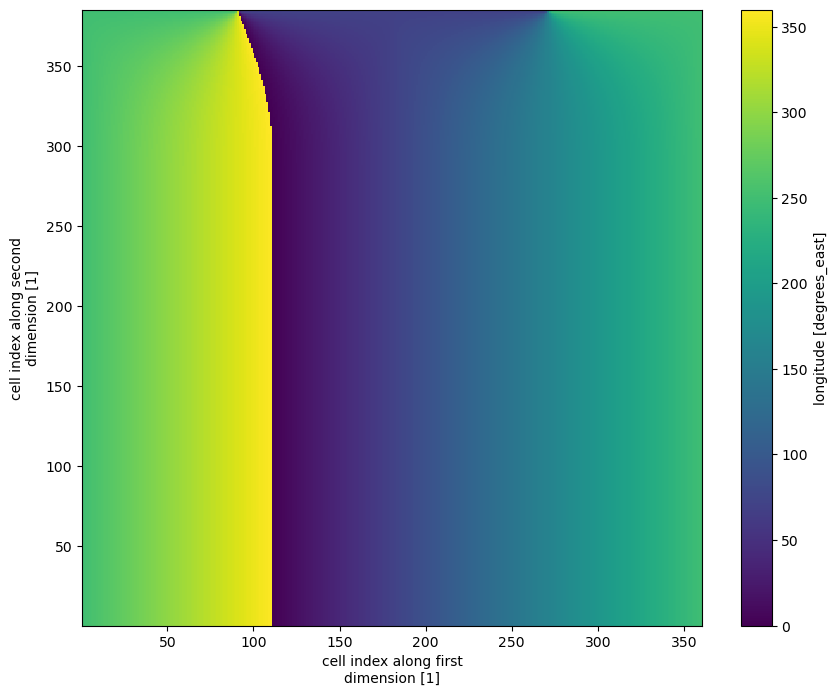

In [5]:
NORESM2_LM_uo.longitude.plot()

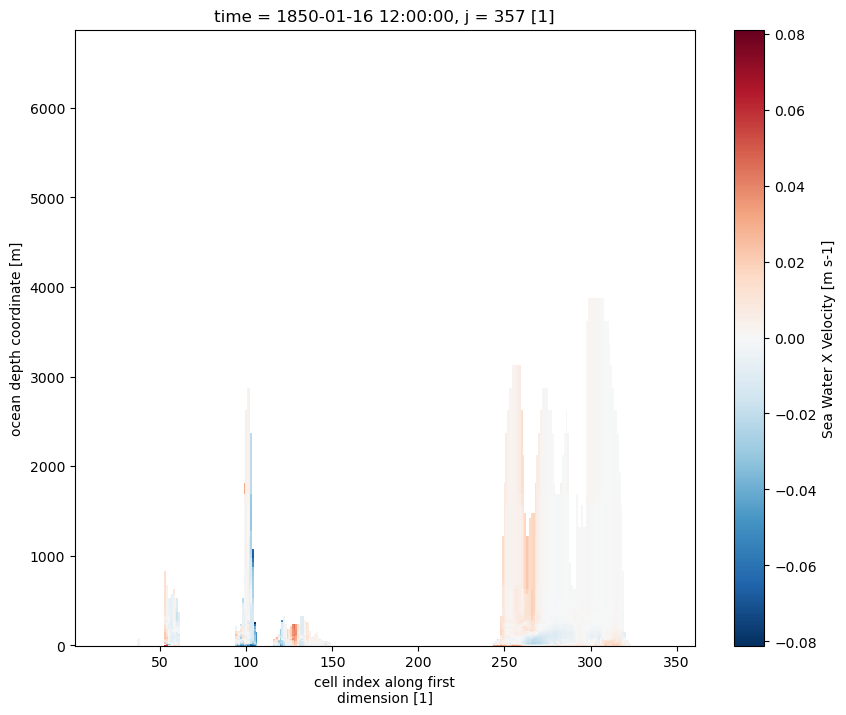

In [6]:
# we can also plot a cross-section along one of the two given dimensions at a given time in order to understand a bit better what kind of data we have.
# Then we don't have to specify the depth level, but the other horizontal dimension, i.e. we slice along j=356 (as an example here)
mpl.rcParams['figure.figsize'] = [10., 8.]
NORESM2_LM_uo.uo.isel(j=356,time=0).plot()

Now the depth increases upward, so let's flip it for more intuitive reading of the plot

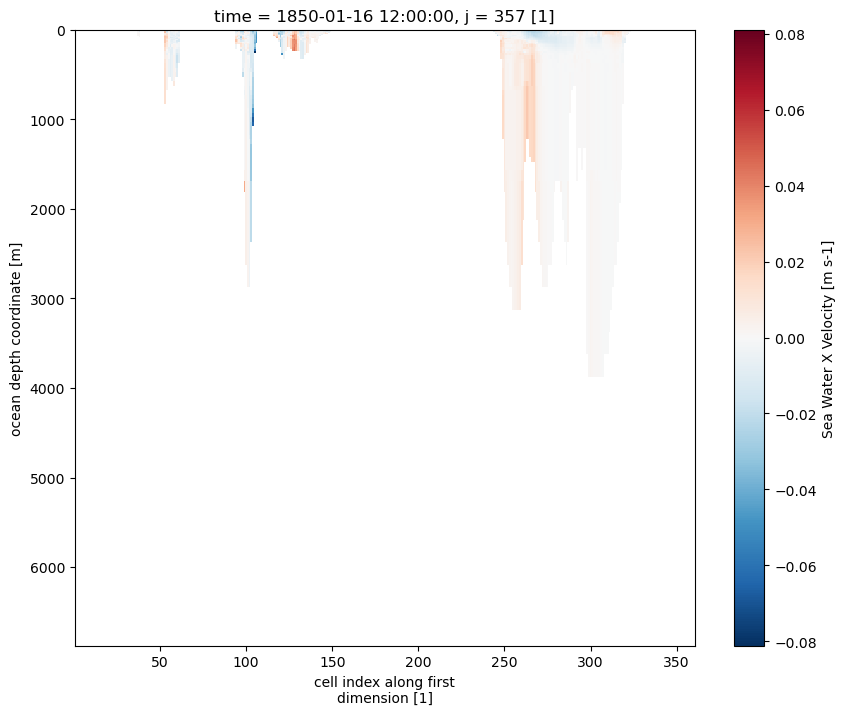

In [7]:
mpl.rcParams['figure.figsize'] = [10., 8.] # set figure size
NORESM2_LM_uo.uo.isel(j=356,time=0).plot() # plot data
plt.gca().invert_yaxis() # get current figure axis and invert the y-axis

## Regridded Version

You can regrid the data to lat/lon (or other coord systems) using cdo:

In [8]:
# import package for this
from cdo import Cdo   # python version
cdo = Cdo()

In [9]:
# OBS! This you only need to run ONCE, as the function stores the regridded dataset as a netcdf at the location you specify (here in the folder of this notebook)
# then you read this netcdf file with the regridded data in as your new datafile
# and then you check whether the regridding worked are reasonably!(!) Nothing unphysical? Good :-)

cdo.remapbil('r360x180', input=NORESM2_LM_uo, output='NORESM2_LM_uo_regridded.nc') # 'r360x180' specifies our common spherical grid, you can choose other ones to transform to if you want, google

'NORESM2_LM_uo_regridded.nc'

In [10]:
# open the regridded data and check
data_regr = xr.open_mfdataset('NORESM2_LM_uo_regridded.nc') # plot exemplary random time
data_regr

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 120, bnds: 2, lev: 70, lat: 180, lon: 360)
Coordinates:
  * time       (time) object 960B 1850-01-16 12:00:00 ... 1859-12-16 12:00:00
  * lev        (lev) float64 560B 0.0 5.0 10.0 ... 6.25e+03 6.5e+03 6.75e+03
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 2kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lev_bnds   (lev, bnds) float64 1kB dask.array<chunksize=(70, 2), meta=np.ndarray>
    uo         (time, lev, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
Attributes: (12/50)
    CDI:                       Climate Data Interface version 2.4.0 (https://...
    Conventions:               CF-1.7 CMIP-6.2
    source:                    NorESM2-LM (2017): \naerosol: OsloAero\natmos:...
    institution:               NorESM Climate modeling Consortium consisting ...
    activity_id:               CMIP
    branch_method:             Hybrid-restart from year 1600-01-01 of piControl
    ...                        ...
    variable_id:               uo
    variant_label:             r1i1p1f1
    license:                   CMIP6 model data produced by NCC is licensed u...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/cfcbada2-a3ca-46f1-8472-4cad9474f6da
    CDO:                       Climate Data Operators version 2.4.0 (https://...

Now the coords are lat, lon and lev. Let's check whether the array and values look reasonable in comparison to before:

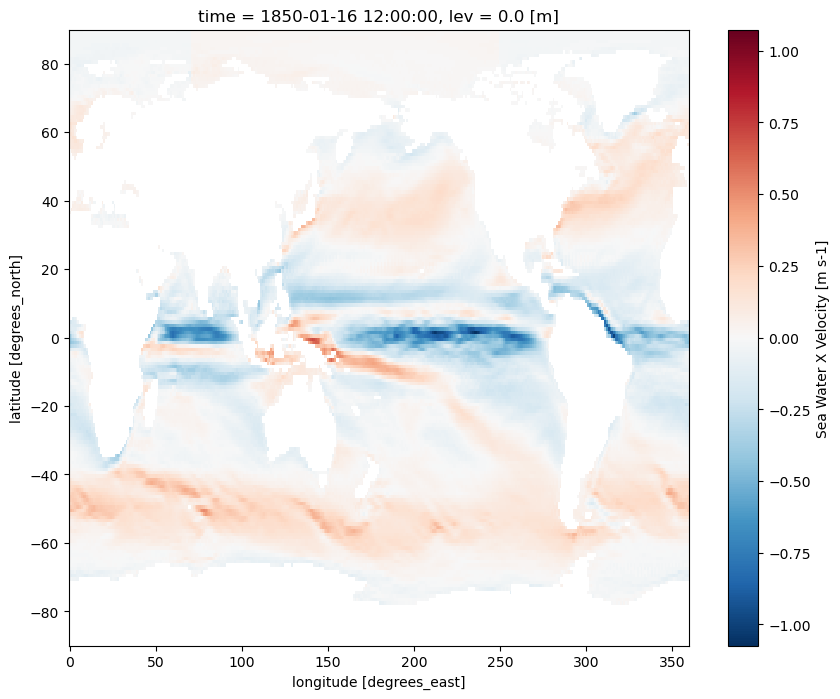

In [11]:
mpl.rcParams['figure.figsize'] = [10., 8.]
data_regr.uo.isel(time=0,lev=0).plot()

In [12]:
# define Transect along latitude 80.5 
transect = data_regr.sel(lat=80.5)

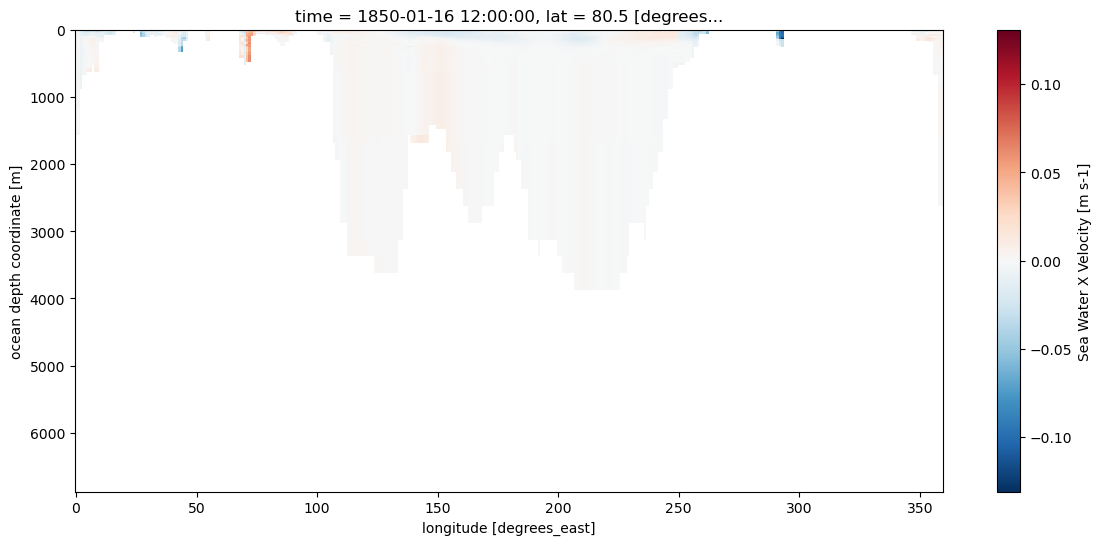

In [13]:
# ... and plot uo along this transect / crossection at lat = 80.5 deg N
fig,ax1 = plt.subplots(1, 1, figsize=(14, 6))
transect.uo.isel(time=0).plot(ax=ax1)
ax1.invert_yaxis()

The ocean floor topography (as defined in the model) is nicely visible and now everything is in understandable coordinates.